In [1]:
import sys
import os

# Add the project root (lab6/) to Python's module search path
project_root = os.path.abspath("..")
sys.path.append(project_root)

import shutil
import random
import xml.etree.ElementTree as ET

import random
!pip install --quiet scikit-learn
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import matplotlib.pyplot as plt
import cv2

from ultralytics import YOLO


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import matplotlib.pyplot as plt

def show_yolo_annotation(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, cx, cy, bw, bh = map(float, line.split())
        cx *= w
        cy *= h
        bw *= w
        bh *= h

        xmin = int(cx - bw/2)
        ymin = int(cy - bh/2)
        xmax = int(cx + bw/2)
        ymax = int(cy + bh/2)

        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255,0,0), 2)
        cv2.putText(img, str(int(cls)), (xmin, ymin-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


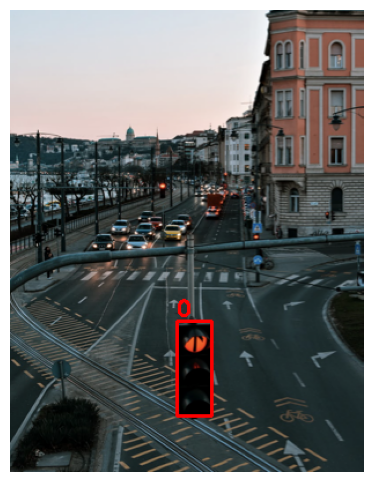

In [3]:
show_yolo_annotation(
    "../data/images/road2.png",
    "../data/annotations/road2.txt"
)

In [4]:
# Rootpath indicates the root folder where you have stored the road-sign-detection dataset
rootpath = "../data"

In [5]:

# Splits dataset into training, validation, test set

# Load image paths
images = [os.path.join(rootpath, 'images', x) for x in os.listdir(os.path.join(rootpath, 'images'))]
# Load annotation paths
annotations = [os.path.join(rootpath,'annotations', x) for x in os.listdir(os.path.join(rootpath,'annotations')) if x[-3:] == "txt"]

# sort both lists
images.sort()
annotations.sort()

# Split train vs validation set
train_images, val_images, train_annotations, val_annotations = train_test_split(images, annotations, test_size = 0.2, random_state = 1)
# Split validation vs train set
val_images, test_images, val_annotations, test_annotations = train_test_split(val_images, val_annotations, test_size = 0.5, random_state = 1)

# These lists tell what files go where when moving them


In [6]:
def move_files_to_folder(list_of_files, destination_folder):
    for f in list_of_files:
        try:
            shutil.move(f, destination_folder)
        except:
            print(f)
            assert False

In [9]:
# move_files_to_folder(train_images, "../data/images/train")
# move_files_to_folder(val_images, "../data/images/val")
# move_files_to_folder(test_images, "../data/images/test")

move_files_to_folder(train_annotations, "../data/labels/train")
move_files_to_folder(val_annotations, "../data/lables/val")
move_files_to_folder(test_annotations, "../data/labels/test")

print(len(os.listdir("../data/images/train")))
print(len(os.listdir("../data/labels/train")))

../data\annotations\road260.txt


AssertionError: 